# Tutorial of *Flow Matching for Applied Mathematicians* : Training of toy models

This notebook enables the reproduction of several figures from the paper *Flow Matching for Applied Mathematicians*. We focus here on the trainind of toy models in 2D. It can also be easily adapted as an introductory tutorial for educational purposes. 

# Packages and illustrations

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from sklearn.datasets import make_moons
from tqdm import tqdm

In [3]:
def gaussian_contour(mean, cov, ax=None, levels=[.5,1,1.5,2], n_points=200, **kwargs):
    """
    Plots contour lines of a two-dimensional Gaussian distribution defined by 
    the given mean and covariance matrix.
    """
    if ax is None:
        fig, ax = plt.subplots()
    
    mean = np.asarray(mean)
    cov = np.asarray(cov)

    stds = np.sqrt(np.diag(cov))
    x = np.linspace(mean[0]-4*stds[0], mean[0]+4*stds[0], n_points)
    y = np.linspace(mean[1]-4*stds[1], mean[1]+4*stds[1], n_points)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))

    inv_cov = np.linalg.inv(cov)
    diff = pos - mean
    mahal = np.einsum('...i,ij,...j->...', diff, inv_cov, diff)

    cs = ax.contour(X, Y, mahal, levels=[l**2 for l in levels], **kwargs)

    ax.plot(mean[0], mean[1], 'o', color=kwargs.get('colors'))

    return cs, ax


def euler_solver(x0,v,n_steps=100,T=1) :
    """
    Adapted for torch.
    Solves an ordinary differential equation using the explicit Euler method.
    Starting from an initial state `x0`, the solver advances the solution over
    the time interval [0, T] using `n_steps` uniformly spaced steps. The vector
    field is provided as a Python function `v(t, x)`. The function returns an
    array containing the complete trajectory, including the initial state.
    """
    times = torch.linspace(0,T,n_steps+1)
    t = times[0]
    xts = torch.zeros((n_steps+1, *x0.shape))
    xt = x0
    xts[0] = xt.clone()
    for i in range(n_steps) :
        dt = times[i+1]-times[i]
        xt = xt+dt*v(torch.full((xt.shape[0],), t),xt)
        xts[i+1] = xt.clone()
        t += dt
    return xts

In [4]:
#We use a consistent color palette throughout the notebook, defined below.
color_source = '#648FFF'
color_target = '#DC267F'
color_trajectories = '#323232'

cmap_path = mpl.colors.LinearSegmentedColormap.from_list(
    "cmap_path",
    [color_source, color_target]
)

# Illustration of the generalization through a learned velocity

We train a flow matching model for an independent coupling $(X_0, X_1)$, where $X_0 \sim \mathcal{N}(0, I)$ can be sampled infinitely, and $X_1$ is given as a finite collection of samples.

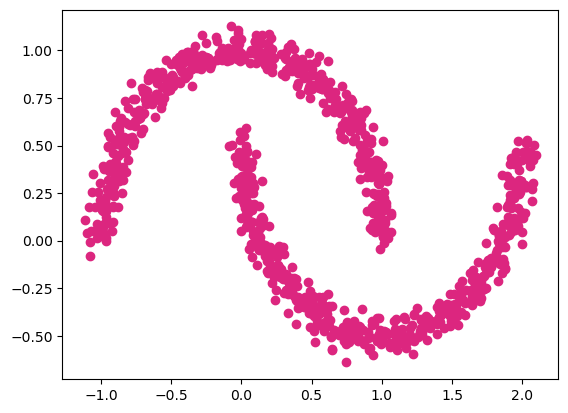

In [5]:
dim = 2

# Construction of X1
n_samples = 10**3

#Two moons
X, _ = make_moons(n_samples=n_samples, noise=.05)
dataset = torch.tensor(X, dtype=torch.float32)
plt.scatter(dataset[:,0],dataset[:,1],color=color_target)
x1 = dataset.clone()

#Spiral

#from sklearn.datasets import make_swiss_roll
# Construction of X1

#X, _ = make_swiss_roll(
#    n_samples=n_samples,
#    noise=0.4,
#    random_state=42
#)

#X = X[:, [0, 2]] 
#dataset = torch.tensor(X, dtype=torch.float32)
#plt.scatter(dataset[:,0],dataset[:,1],color=color_target)
#x1 = dataset.clone()

We parametrize a very simple neural network for 2D examples.

In [5]:
class VelocityField(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim+1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, dim)
        )
    def forward(self, t, x):
        t = t.view(-1,1)
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

Below, it is the training by minimizing the Flow Matching loss

$$
L(\theta) = \int_0^1 \mathbb{E}\| v^\theta (t,X_t) - (X_1 - X_0)\|^2dt
$$

In [6]:
# --- Training parameters---
n_epochs = 10**4
lr = 1e-3
batch_size = 100
model = VelocityField(dim)
optimizer = optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.MSELoss()

## Training
for epoch in tqdm(range(n_epochs)):
    perm = torch.randperm(x1.size(0))
    
    for i in range(0, x1.size(0), batch_size):
        batch_x0 = torch.randn(batch_size,dim)
        idx = perm[i : i + batch_size]
        batch_x1 = x1[idx]
        
        t = torch.rand(batch_size)
        
        xt = (1-t).view(-1,1)*batch_x0 + t.view(-1,1)*batch_x1
        
        v_target = batch_x1 - batch_x0
        v_pred = model(t, xt)
        
        loss = loss_fn(v_pred, v_target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    


100%|████████████████████████████████████| 10000/10000 [00:39<00:00, 254.35it/s]


Below, in black, are the points sampled using the learned velocity, and in pink the training samples of $X_1$.


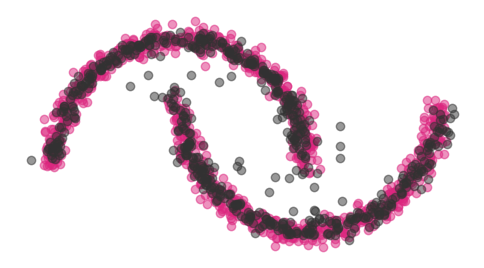

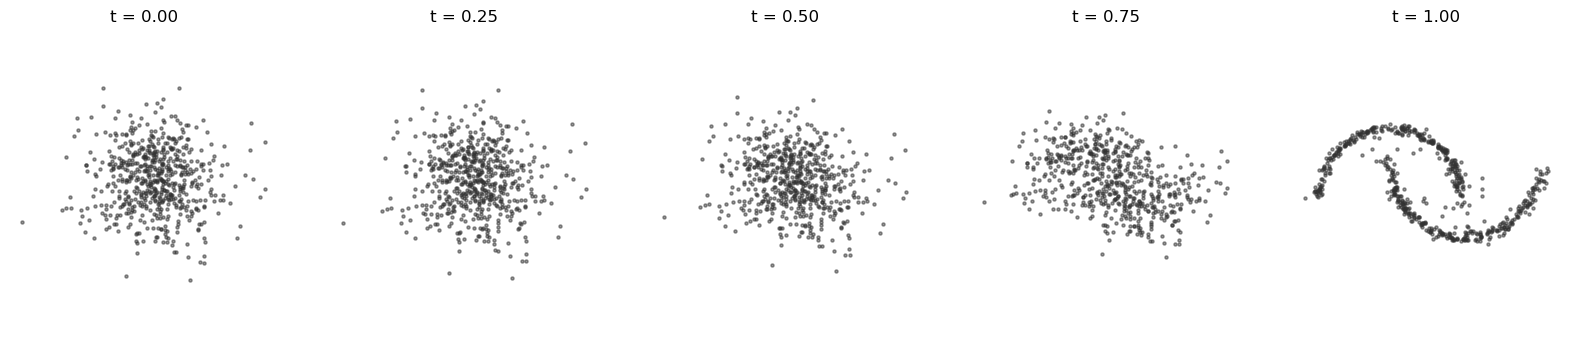

In [7]:
n_traj = 600
x0 = torch.randn(n_traj,2)
steps = 20

xts = euler_solver(x0,model,n_steps=steps)

xts_np = xts.detach().numpy()
x1_theta = xts[-1].detach().numpy()
x0_np = x0.detach().numpy()
x1_np = x1.detach().numpy()

plt.figure(figsize=(6,6))
plt.scatter(x1_np[:,0], x1_np[:,1], alpha=0.5, color=color_target)
plt.scatter(x1_theta[:,0], x1_theta[:,1], alpha=0.5,color=color_trajectories)
plt.axis('equal')
plt.axis('off')
#plt.legend()
plt.axis('scaled')
plt.show()

## Evolution of the sampled points
nb_obs = 5
fig, ax = plt.subplots(1, nb_obs, figsize=(4*nb_obs, 4))
times = np.linspace(0, 1, 21)
times_obs = np.linspace(0, 1, nb_obs) 
idx_obs = np.round(times_obs * (len(times)-1)).astype(int)
for i, idx in enumerate(idx_obs):
    points = xts_np[idx]     # shape (600, 2)
    
    ax[i].scatter(points[:,0], points[:,1], s=5, alpha=0.5,color=color_trajectories)
    ax[i].set_title(f"t = {times[idx]:.2f}")
    ax[i].axis('equal')
    ax[i].axis('off')

# Illustration of the generalization through a learned velocity

As studied by [Bertrand et al., 2025], the learned velocity allows for generalization of the samples produces by the Flow Matching procedure. We propose below the reproduction of the illustrative figure of our paper.

[Bertrand et al., 2025] Quentin Bertrand, Anne Gagneux, Mathurin Massias, & Remi Emonet (2025). On the Closed-Form of Flow Matching: Generalization Does Not Arise from Target Stochasticity. In The Thirty-ninth Annual Conference on Neural Information Processing Systems.

(-4.375379610061645, 4.398827600479126, -4.393547081947327, 4.393547081947327)

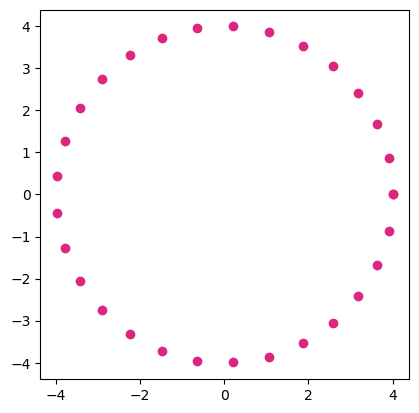

In [8]:
dim = 2

# Construction of X1
radius = 4.0
n_samples = 30
#torch.manual_seed(7)
#angles = 2*torch.pi*torch.rand(n_samples)
angles = torch.linspace(0, 2*torch.pi,n_samples)

x = radius * np.cos(angles)
y = radius * np.sin(angles)

dataset = torch.tensor(np.stack([x, y], axis=1),dtype=torch.float32)
x1 = dataset.clone()
plt.scatter(dataset[:,0],dataset[:,1],color=color_target)
plt.axis('scaled')

In [9]:
class VelocityField(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim+1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, dim)
        )
    def forward(self, t, x):
        t = t.view(-1,1)
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

In [10]:
model_circle = VelocityField(dim)
n_epochs = 10**5
lr = 1e-3
batch_size = 10
optimizer = optim.Adam(model_circle.parameters(), lr=lr)
loss_fn = nn.MSELoss()

## Training
for epoch in tqdm(range(n_epochs)):
    perm = torch.randperm(x1.size(0))
    
    for i in range(0, x1.size(0), batch_size):
        batch_x0 = torch.randn(batch_size,dim)
        idx = perm[i : i + batch_size]
        batch_x1 = x1[idx]
        
    
        # temps t
        t = torch.rand(batch_size)
        
        # interpolation X_t
        xt = (1-t).view(-1,1)*batch_x0 + t.view(-1,1)*batch_x1
        
        # cible : x1 - x0
        v_target = batch_x1 - batch_x0
        v_pred = model_circle(t,xt)
        
        loss = loss_fn(v_pred, v_target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    


100%|█████████████████████████████████| 100000/100000 [01:38<00:00, 1010.56it/s]


Observe below that the generated samples cover the entire circle.

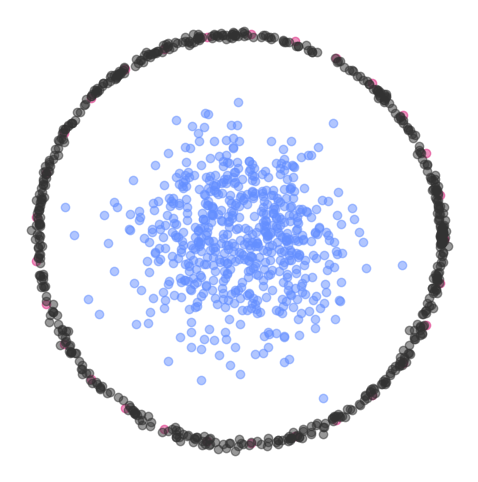

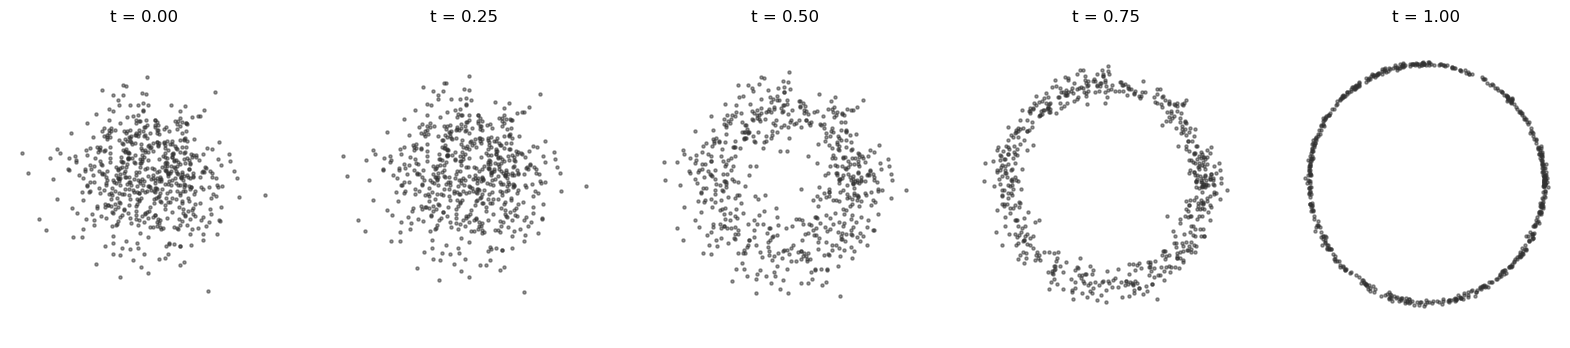

In [11]:
n_traj = 600
x0 = torch.randn(n_traj,2)
steps = 20

xts = euler_solver(x0,model_circle,n_steps=steps)

x1_theta = xts[-1].detach().numpy()
x0_np = x0.detach().numpy()
x1_np = x1.detach().numpy()
xts_np = xts.detach().numpy()

plt.figure(figsize=(6,6))
plt.scatter(x0_np[:,0], x0_np[:,1], alpha=0.5,color=color_source)
plt.scatter(x1_np[:,0], x1_np[:,1], alpha=0.5, color=color_target)
plt.scatter(x1_theta[:,0], x1_theta[:,1], alpha=0.5,color=color_trajectories)
plt.axis('equal')
plt.axis('off')
#plt.legend()
plt.axis('scaled')
plt.show()

## Evolution of the sampled points
nb_obs = 5
fig, ax = plt.subplots(1, nb_obs, figsize=(4*nb_obs, 4))
times = np.linspace(0, 1, 21)
times_obs = np.linspace(0, 1, nb_obs) 
idx_obs = np.round(times_obs * (len(times)-1)).astype(int)
for i, idx in enumerate(idx_obs):
    # On récupère tous les points à cet instant :
    points = xts_np[idx]     # shape (600, 2)
    
    ax[i].scatter(points[:,0], points[:,1], s=5, alpha=0.5,color=color_trajectories)
    ax[i].set_title(f"t = {times[idx]:.2f}")
    ax[i].axis('equal')
    ax[i].axis('off')